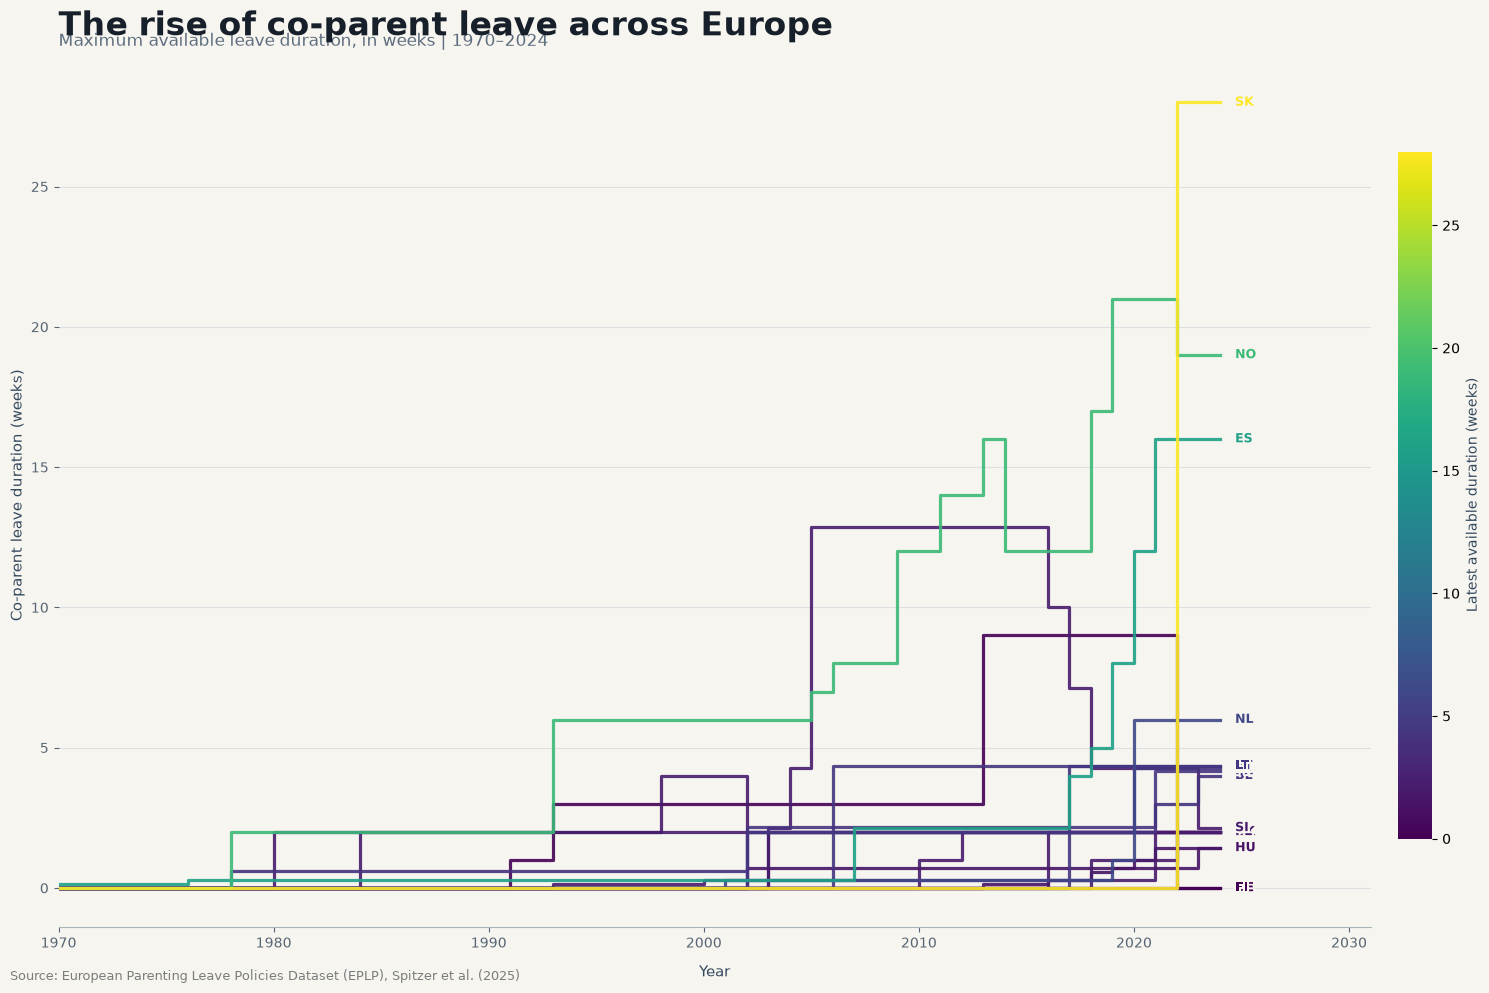

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --------------------------------------------------
# Load EPLP data
# --------------------------------------------------

url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/"
    "data/2026/2026-06-02/eplp.csv"
)

df = pd.read_csv(url)

# Make sure year and co-parent leave are numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["co_ld"] = pd.to_numeric(df["co_ld"], errors="coerce")

# Remove invalid negative values
df.loc[df["co_ld"] < 0, "co_ld"] = np.nan

# --------------------------------------------------
# Find each country's latest available policy
# --------------------------------------------------

latest = (
    df.dropna(subset=["co_ld"])
      .sort_values(["country", "year"])
      .groupby("country")
      .tail(1)
      .set_index("country")["co_ld"]
)

# Sort countries by latest leave duration
countries = latest.sort_values().index.tolist()

# Color scale
norm = Normalize(
    vmin=latest.min(),
    vmax=latest.max()
)

cmap = plt.colormaps["viridis"]

# --------------------------------------------------
# Create plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 10))

background = "#F7F5F0"
text_dark = "#17202A"
text_gray = "#5D6D7E"
grid_color = "#D5D8DC"

fig.patch.set_facecolor(background)
ax.set_facecolor(background)

# --------------------------------------------------
# Plot each country
# --------------------------------------------------

for country in countries:

    country_data = (
        df[df["country"] == country]
        .sort_values("year")[["year", "co_ld"]]
        .dropna(subset=["co_ld"])
    )

    if country_data.empty:
        continue

    color = cmap(norm(latest[country]))

    ax.step(
        country_data["year"],
        country_data["co_ld"],
        where="post",
        color=color,
        linewidth=2.3,
        alpha=0.9,
    )

    # Latest available point
    last_year = country_data["year"].iloc[-1]
    last_value = country_data["co_ld"].iloc[-1]

    # Country label
    ax.text(
        last_year + 0.5,
        last_value,
        f" {country}",
        color=color,
        fontsize=9,
        va="center",
        fontweight="bold",
        path_effects=[
            pe.withStroke(
                linewidth=3,
                foreground=background
            )
        ],
    )

# --------------------------------------------------
# Titles
# --------------------------------------------------

ax.set_title(
    "The rise of co-parent leave across Europe",
    loc="left",
    fontsize=24,
    fontweight="bold",
    color=text_dark,
    pad=20,
)

ax.text(
    0,
    1.02,
    "Maximum available leave duration, in weeks | 1970–2024",
    transform=ax.transAxes,
    fontsize=12,
    color=text_gray,
)

# --------------------------------------------------
# Axis labels
# --------------------------------------------------

ax.set_xlabel(
    "Year",
    fontsize=11,
    color="#34495E",
    labelpad=10,
)

ax.set_ylabel(
    "Co-parent leave duration (weeks)",
    fontsize=11,
    color="#34495E",
)

# --------------------------------------------------
# Grid
# --------------------------------------------------

ax.grid(
    axis="y",
    color=grid_color,
    linewidth=0.8,
    alpha=0.7,
)

ax.grid(
    axis="x",
    visible=False,
)

# --------------------------------------------------
# Spines
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#AAB7B8")

# Explicitly set tick colors
ax.tick_params(
    axis="both",
    colors="#566573",
)

# Leave room for country labels
ax.set_xlim(
    df["year"].min(),
    df["year"].max() + 7,
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

sm = ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02,
    fraction=0.025,
)

cbar.set_label(
    "Latest available duration (weeks)",
    color="#34495E",
)

cbar.outline.set_visible(False)

# --------------------------------------------------
# Source
# --------------------------------------------------

fig.text(
    0.01,
    0.015,
    "Source: European Parenting Leave Policies Dataset (EPLP), Spitzer et al. (2025)",
    fontsize=9,
    color="#7B7D7D",
)

# --------------------------------------------------
# Final layout
# --------------------------------------------------

plt.tight_layout()
plt.show()